# 0050 Route 1 - Existing Strategies + Partial TP / Drawdown Exit

這版新增兩個策略：
- 觸發固定停利後先部分出場 1/3，剩餘部位採 **高點回跌 8%** 出場
- 觸發固定停利後先部分出場 1/3，剩餘部位採 **高點回跌 10%** 出場

另外已將 **證交稅改為 0.1% (`SELL_TAX = 0.001`)**。

為了避免再發生函式尚未定義的問題，所有函式與主程式都放在同一個 code cell。
- 新增純固定停利/停損分批出場策略：+20% 或 -15% 先出場 1/3，剩餘部位依觸發價重新計算 -10% 停損；若先觸發 -15% 後反彈回原 +20%，則再依停利條件分批處理。


===== Raw Comparison Table =====


,Strategy,Final Equity,Total PnL,Total Return,Annualized Return,Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Avg Cycle Return,Beta vs Benchmark A,Daily Alpha vs Benchmark A,Annualized Alpha vs Benchmark A,Raw Entry Signals,Executed Entries,Exit Events,Total Units Bought,Completed Cycles,Total Cost,Total Contribution
0,Fixed +20% / -15% Exit,9.014971e+05,-9.850295e+04,-0.098503,-0.009696,0.163806,0.021938,-0.546510,0.450000,0.003715,0.201320,-0.000147,-0.037125,134,124,20,328000.0,20,64753.493522,1000000
1,ATR Baseline - 4ATR Yo-Yo + 20% TP,9.907130e+05,-9.287018e+03,-0.009287,-0.000876,0.103784,0.043025,-0.389474,0.321429,0.002337,0.089735,-0.000054,-0.013685,134,127,28,358000.0,28,69662.325049,1000000
2,"Partial TP 1/3 at +20%, Then 8% Peak Drawdown ...",1.004831e+06,4.830511e+03,0.004831,0.000453,0.162332,0.083518,-0.537594,0.473684,0.009590,0.206972,-0.000112,-0.028305,134,128,19,349000.0,19,69335.167230,1000000
3,"Partial TP 1/3 at +20%, Then 10% Peak Drawdown...",1.137268e+06,1.372682e+05,0.137268,0.012159,0.165766,0.155309,-0.545297,0.444444,0.020925,0.220050,-0.000074,-0.018762,134,125,18,320000.0,18,63690.804021,1000000
4,Candidate C - ADX-Regime Chandelier + RSI Stre...,1.336215e+06,3.362148e+05,0.336215,0.027608,0.103504,0.314329,-0.324078,0.333333,0.014017,0.093546,0.000054,0.013614,134,123,27,372000.0,27,73041.025816,1000000
5,Candidate A - Dynamic Chandelier 4→3→2 ATR,1.342704e+06,3.427042e+05,0.342704,0.028075,0.117409,0.293850,-0.397509,0.333333,0.016409,0.114692,0.000045,0.011303,134,125,27,365000.0,27,71717.369755,1000000
6,Candidate B - Dynamic Chandelier + Yo-Yo Suppl...,1.370813e+06,3.708128e+05,0.370813,0.030079,0.116469,0.312024,-0.400487,0.370370,0.016957,0.113981,0.000053,0.013287,134,125,27,372000.0,27,73562.589056,1000000
7,ATR Variant 3 - Base Entry Breakeven + Close 3ATR,2.375621e+06,1.375621e+06,1.375621,0.084696,0.146533,0.626989,-0.397437,0.285714,0.054805,0.160339,0.000236,0.059444,134,122,28,383000.0,28,78405.427199,1000000
8,"Fixed Partial TP/SL: +20% or -15% Sell 1/3, Re...",2.575475e+06,1.575475e+06,1.575475,0.092959,0.336375,0.432148,-0.681434,0.666667,-0.010936,0.691012,0.000022,0.005599,134,44,3,92000.0,3,16114.404685,1000000
9,ATR Variant 1 - Chandelier Close 4ATR Ratchet,3.488488e+06,2.488488e+06,2.488488,0.124569,0.171722,0.768323,-0.447344,0.260870,0.006584,0.215630,0.000350,0.088324,134,122,23,365000.0,23,78129.580074,1000000


===== Styled Comparison Table =====


,Strategy,Final Equity,Total PnL,Total Return,Annualized Return,Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Avg Cycle Return,Beta vs Benchmark A,Daily Alpha vs Benchmark A,Annualized Alpha vs Benchmark A,Raw Entry Signals,Executed Entries,Exit Events,Total Units Bought,Completed Cycles,Total Cost,Total Contribution
0,Fixed +20% / -15% Exit,"901,497","-98,503",-9.85%,-0.97%,16.38%,0.022,-54.65%,45.00%,0.37%,0.201,-0.01473%,-3.71%,134,124,20,"328,000",20,"64,753","1,000,000"
1,ATR Baseline - 4ATR Yo-Yo + 20% TP,"990,713","-9,287",-0.93%,-0.09%,10.38%,0.043,-38.95%,32.14%,0.23%,0.090,-0.00543%,-1.37%,134,127,28,"358,000",28,"69,662","1,000,000"
2,"Partial TP 1/3 at +20%, Then 8% Peak Drawdown Exit","1,004,831","4,831",0.48%,0.05%,16.23%,0.084,-53.76%,47.37%,0.96%,0.207,-0.01123%,-2.83%,134,128,19,"349,000",19,"69,335","1,000,000"
3,"Partial TP 1/3 at +20%, Then 10% Peak Drawdown Exit","1,137,268","137,268",13.73%,1.22%,16.58%,0.155,-54.53%,44.44%,2.09%,0.220,-0.00745%,-1.88%,134,125,18,"320,000",18,"63,691","1,000,000"
4,Candidate C - ADX-Regime Chandelier + RSI Strength Exit,"1,336,215","336,215",33.62%,2.76%,10.35%,0.314,-32.41%,33.33%,1.40%,0.094,0.00540%,1.36%,134,123,27,"372,000",27,"73,041","1,000,000"
5,Candidate A - Dynamic Chandelier 4→3→2 ATR,"1,342,704","342,704",34.27%,2.81%,11.74%,0.294,-39.75%,33.33%,1.64%,0.115,0.00449%,1.13%,134,125,27,"365,000",27,"71,717","1,000,000"
6,Candidate B - Dynamic Chandelier + Yo-Yo Supplement,"1,370,813","370,813",37.08%,3.01%,11.65%,0.312,-40.05%,37.04%,1.70%,0.114,0.00527%,1.33%,134,125,27,"372,000",27,"73,563","1,000,000"
7,ATR Variant 3 - Base Entry Breakeven + Close 3ATR,"2,375,621","1,375,621",137.56%,8.47%,14.65%,0.627,-39.74%,28.57%,5.48%,0.160,0.02359%,5.94%,134,122,28,"383,000",28,"78,405","1,000,000"
8,"Fixed Partial TP/SL: +20% or -15% Sell 1/3, Remaining 2/3 Exit at -10% from Trigger","2,575,475","1,575,475",157.55%,9.30%,33.64%,0.432,-68.14%,66.67%,-1.09%,0.691,0.00222%,0.56%,134,44,3,"92,000",3,"16,114","1,000,000"
9,ATR Variant 1 - Chandelier Close 4ATR Ratchet,"3,488,488","2,488,488",248.85%,12.46%,17.17%,0.768,-44.73%,26.09%,0.66%,0.216,0.03505%,8.83%,134,122,23,"365,000",23,"78,130","1,000,000"


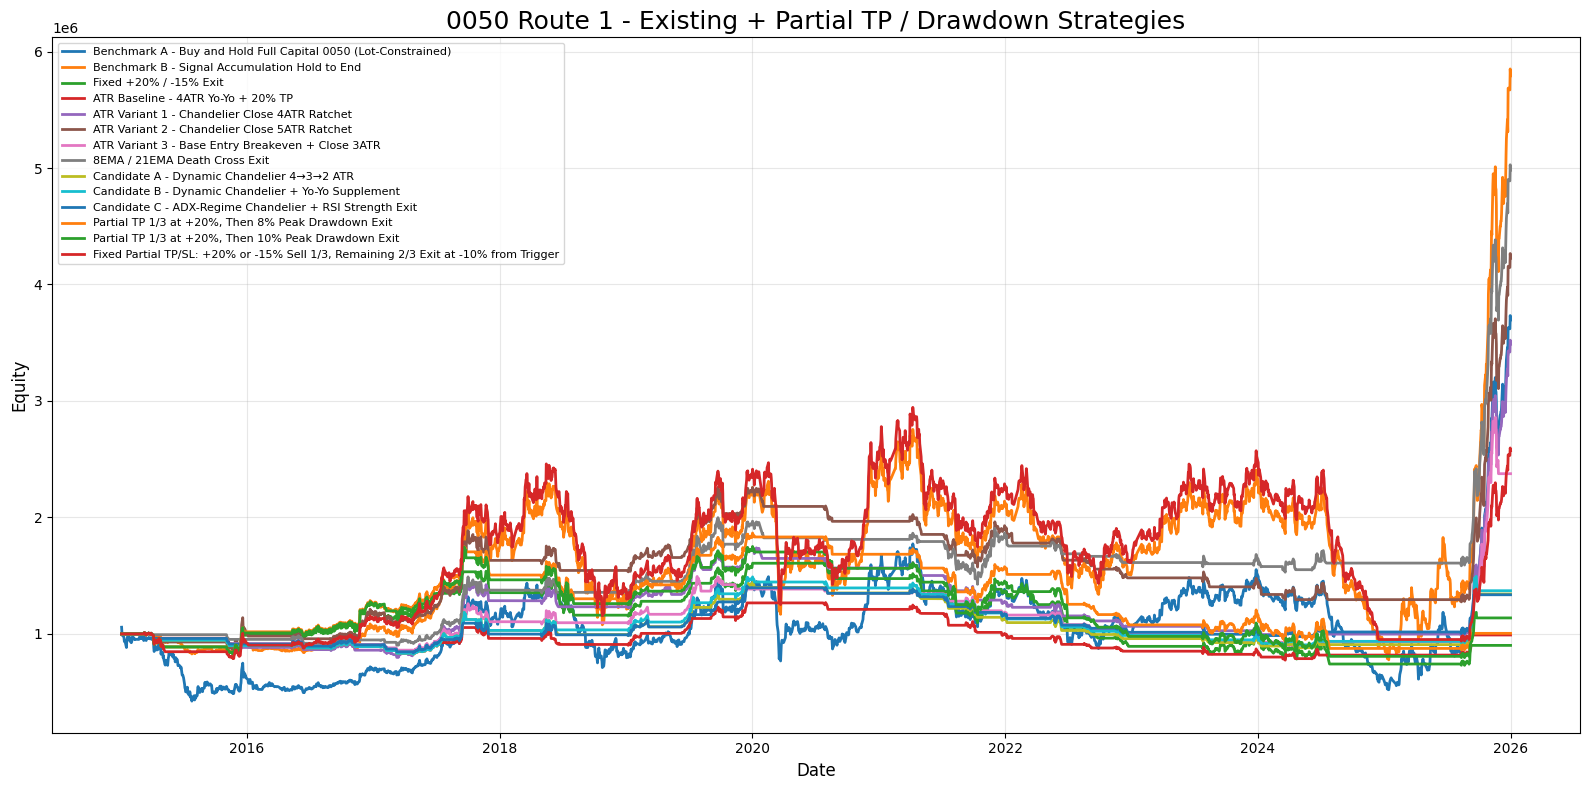

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 520)

# =========================================================
# 0. Parameters
# =========================================================
SYMBOL = "2408"
CSV_PATH = "2408_OHLCV.csv"

INITIAL_CAPITAL = 1_000_000
TRADING_DAYS = 252

BUY_FEE = 0.001425
SELL_FEE = 0.001425
SELL_TAX = 0.001   # changed to 0.1%

LOT_SHARES = 1000

INITIAL_ENTRY_FRACTION = 0.50
ADDON_MIN_DISTANCE_ATR = 1.0

LENGTH = 20
MULT = 2.0
LENGTH_KC = 20
MULT_KC = 1.5

ATR_PERIOD = 14
YOYO_ATR_MULT = 4.0
TAKE_PROFIT_PCT = 0.20
STOP_LOSS_PCT = -0.15

CHAND_CLOSE_4_MULT = 4.0
CHAND_CLOSE_5_MULT = 5.0

BREAKEVEN_INIT_ATR = 2.0
BREAKEVEN_TRIGGER_ATR = 2.0
BREAKEVEN_TRAIL_MULT = 3.0

CAND_INIT_STOP_ATR = 2.5
CAND_A_STAGE1_ATR = 4.0
CAND_A_STAGE2_ATR = 3.0
CAND_A_STAGE3_ATR = 2.0
CAND_A_TIGHTEN1_PROFIT_ATR = 4.0
CAND_A_TIGHTEN2_PROFIT_ATR = 6.0

CAND_B_YY_ATR = 2.0
CAND_B_YY_PROFIT_ATR = 2.0

CAND_C_ADX_STRONG_ATR = 4.0
CAND_C_ADX_WEAK_ATR = 3.0
CAND_C_RSI_EXIT_PROFIT_ATR = 6.0
CAND_C_RSI_EXIT_LEVEL = 75.0

PARTIAL_TP_FRACTION = 1 / 3
PARTIAL_TP_LEVEL = 0.20
PARTIAL_DD_8 = 0.08
PARTIAL_DD_10 = 0.10

# Pure fixed partial exit strategy parameters
FIXED_PARTIAL_TP_LEVEL = 0.20
FIXED_PARTIAL_INITIAL_SL_LEVEL = -0.15
FIXED_PARTIAL_AFTER_TRIGGER_SL = 0.10

EMA_FAST = 8
EMA_SLOW = 21

ADX_PERIOD = 14
RSI_PERIOD = 14

# =========================================================
# 1. Data loading
# =========================================================
def load_data():
    df = pd.read_csv(CSV_PATH)

    rename_map = {
        "年月日": "date",
        "日期": "date",
        "Date": "date",
        "date": "date",
        "開盤價(元)": "open",
        "最高價(元)": "high",
        "最低價(元)": "low",
        "收盤價(元)": "close",
        "成交量(千股)": "volume",
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume",
    }
    df = df.rename(columns=rename_map)

    needed = ["date", "open", "high", "low", "close"]
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    df["date"] = pd.to_datetime(df["date"])

    for c in ["open", "high", "low", "close", "volume"]:
        if c in df.columns:
            df[c] = (
                df[c].astype(str)
                .str.replace(",", "", regex=False)
                .replace("nan", np.nan)
            )
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.set_index("date").sort_index()

# =========================================================
# 2. Indicator helpers
# =========================================================
def true_range(df: pd.DataFrame) -> pd.Series:
    prev_close = df["close"].shift(1)
    tr1 = df["high"] - df["low"]
    tr2 = (df["high"] - prev_close).abs()
    tr3 = (df["low"] - prev_close).abs()
    return pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

def wilder_rma(series: pd.Series, length: int) -> pd.Series:
    series = series.astype(float)
    values = series.values
    out = np.full(len(values), np.nan, dtype=float)

    if len(values) < length:
        return pd.Series(out, index=series.index)

    first_avg = np.nanmean(values[:length])
    out[length - 1] = first_avg
    alpha = 1.0 / length

    for i in range(length, len(values)):
        prev = out[i - 1]
        curr = values[i]

        if np.isnan(prev):
            prev = curr
        if np.isnan(curr):
            out[i] = prev
        else:
            out[i] = prev + alpha * (curr - prev)

    return pd.Series(out, index=series.index)

def atr_wilder(df: pd.DataFrame, length: int = ATR_PERIOD) -> pd.Series:
    return wilder_rma(true_range(df), length)

def rsi_wilder(close: pd.Series, length: int = RSI_PERIOD) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)

    avg_gain = wilder_rma(gain.fillna(0.0), length)
    avg_loss = wilder_rma(loss.fillna(0.0), length)

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    rsi = rsi.where(avg_loss != 0, 100.0)
    rsi = rsi.where(avg_gain != 0, 0.0).where(~((avg_gain == 0) & (avg_loss == 0)), 50.0)
    return rsi

def adx_wilder(df: pd.DataFrame, length: int = ADX_PERIOD):
    high = df["high"]
    low = df["low"]

    up_move = high.diff()
    down_move = -low.diff()

    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=df.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=df.index)

    atr = wilder_rma(true_range(df).fillna(0.0), length)
    plus_dm_sm = wilder_rma(plus_dm, length)
    minus_dm_sm = wilder_rma(minus_dm, length)

    plus_di = 100 * plus_dm_sm / atr.replace(0, np.nan)
    minus_di = 100 * minus_dm_sm / atr.replace(0, np.nan)

    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx = wilder_rma(dx.fillna(0.0), length)
    return plus_di, minus_di, adx

def rolling_linreg_last(y: pd.Series, window: int) -> pd.Series:
    x = np.arange(window)
    x_mean = x.mean()
    denom = ((x - x_mean) ** 2).sum()

    def calc(arr: np.ndarray) -> float:
        if np.isnan(arr).any():
            return np.nan
        y_mean = arr.mean()
        slope = ((x - x_mean) * (arr - y_mean)).sum() / denom
        intercept = y_mean - slope * x_mean
        return intercept + slope * (window - 1)

    return y.rolling(window).apply(calc, raw=True)

def initial_entry_lots(affordable: int, fraction: float = INITIAL_ENTRY_FRACTION) -> int:
    if affordable <= 0:
        return 0
    lots = int(np.floor(affordable * fraction))
    lots = max(1, lots)
    return min(lots, affordable)

# =========================================================
# 3. Indicators and signals
# =========================================================
def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    close = df["close"]
    high = df["high"]
    low = df["low"]

    basis = close.rolling(LENGTH).mean()
    dev = MULT * close.rolling(LENGTH).std(ddof=0)
    df["upperBB"] = basis + dev
    df["lowerBB"] = basis - dev

    ma = close.rolling(LENGTH_KC).mean()
    tr = true_range(df)
    range_ma = tr.rolling(LENGTH_KC).mean()
    df["upperKC"] = ma + range_ma * MULT_KC
    df["lowerKC"] = ma - range_ma * MULT_KC

    df["sqzOn"] = (df["lowerBB"] > df["lowerKC"]) & (df["upperBB"] < df["upperKC"])
    df["sqzOff"] = (df["lowerBB"] < df["lowerKC"]) & (df["upperBB"] > df["upperKC"])

    highest_high = high.rolling(LENGTH_KC).max()
    lowest_low = low.rolling(LENGTH_KC).min()
    mean_hl = (highest_high + lowest_low) / 2
    mean_all = (mean_hl + ma) / 2
    momentum_input = close - mean_all
    df["squeeze_mom"] = rolling_linreg_last(momentum_input, LENGTH_KC)

    df["tr"] = tr
    df["prev_close"] = close.shift(1)
    df["atr14"] = atr_wilder(df, ATR_PERIOD)
    df["atr14_prev"] = df["atr14"].shift(1)

    df["ema8"] = close.ewm(span=EMA_FAST, adjust=False).mean()
    df["ema21"] = close.ewm(span=EMA_SLOW, adjust=False).mean()

    df["rsi14"] = rsi_wilder(close, RSI_PERIOD)
    df["rsi14_prev"] = df["rsi14"].shift(1)

    plus_di, minus_di, adx = adx_wilder(df, ADX_PERIOD)
    df["plus_di14"] = plus_di
    df["minus_di14"] = minus_di
    df["adx14"] = adx
    df["adx14_prev"] = df["adx14"].shift(1)
    df["adx14_prev2"] = df["adx14"].shift(2)

    return df

def generate_signals(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    mom = out["squeeze_mom"]

    out["sqz_on_3"] = (
        out["sqzOn"].fillna(False) &
        out["sqzOn"].shift(1).fillna(False) &
        out["sqzOn"].shift(2).fillna(False)
    )

    out["mom_positive_continue"] = (
        (mom > 0) &
        (mom.shift(1) > 0) &
        (mom.shift(2) > 0)
    )

    out["mom_negative_improving"] = (
        (mom < 0) &
        (mom.shift(1) < 0) &
        (mom.shift(2) < 0) &
        (mom.shift(2) < mom.shift(1)) &
        (mom.shift(1) < mom)
    )

    out["mom_negative_to_positive"] = (
        (mom.shift(2) < 0) &
        (mom.shift(1) > 0) &
        (mom > 0)
    )

    out["entry_signal_long"] = out["sqz_on_3"] & (
        out["mom_positive_continue"] |
        out["mom_negative_improving"] |
        out["mom_negative_to_positive"]
    )

    out["ema_death_cross"] = (
        (out["ema8"].shift(1) >= out["ema21"].shift(1)) &
        (out["ema8"] < out["ema21"])
    )
    return out

# =========================================================
# 4. Exit helpers
# =========================================================
def resolve_stop_tp_exit(open_price, high_price, low_price, stop_price, tp_price, prefix):
    if open_price <= stop_price:
        return open_price, f"{prefix}_stop_gap_open"
    if open_price >= tp_price:
        return open_price, f"{prefix}_tp_gap_open"

    hit_stop = low_price <= stop_price
    hit_tp = high_price >= tp_price

    if hit_stop and hit_tp:
        return stop_price, f"{prefix}_same_bar_both_hit_conservative_stop"
    if hit_stop:
        return stop_price, f"{prefix}_stop_intraday"
    if hit_tp:
        return tp_price, f"{prefix}_tp_intraday"

    return None, None

def resolve_stop_only_exit(open_price, low_price, stop_price, prefix):
    if open_price <= stop_price:
        return open_price, f"{prefix}_gap_open"
    if low_price <= stop_price:
        return stop_price, f"{prefix}_intraday"
    return None, None

def partial_tp_event(open_price, high_price, low_price, stop_price, tp_price):
    if open_price <= stop_price:
        return "full_stop", open_price, "partial_full_stop_gap_open"
    if open_price >= tp_price:
        return "partial_tp", open_price, "partial_tp_gap_open"

    hit_stop = low_price <= stop_price
    hit_tp = high_price >= tp_price

    if hit_stop and hit_tp:
        return "full_stop", stop_price, "partial_same_bar_both_hit_conservative_stop"
    if hit_stop:
        return "full_stop", stop_price, "partial_full_stop_intraday"
    if hit_tp:
        return "partial_tp", tp_price, "partial_tp_intraday"

    return None, None, None

def profit_atr_from_high(position_close_high, base_entry_price, base_entry_atr):
    if np.isnan(position_close_high) or np.isnan(base_entry_price) or np.isnan(base_entry_atr) or base_entry_atr == 0:
        return np.nan
    return (position_close_high - base_entry_price) / base_entry_atr

def candidate_a_chain_mult(profit_atr):
    if np.isnan(profit_atr):
        return CAND_A_STAGE1_ATR
    if profit_atr >= CAND_A_TIGHTEN2_PROFIT_ATR:
        return CAND_A_STAGE3_ATR
    if profit_atr >= CAND_A_TIGHTEN1_PROFIT_ATR:
        return CAND_A_STAGE2_ATR
    return CAND_A_STAGE1_ATR

def adx_is_rising(adx_prev, adx_prev2):
    if pd.isna(adx_prev) or pd.isna(adx_prev2):
        return None
    return bool(float(adx_prev) > float(adx_prev2))

def compute_candidate_stop(
    mode, atr_ref, base_entry_price, base_entry_atr, position_high_prev,
    position_close_high_prev, prev_close_price, adx_prev, adx_prev2, current_trail_stop
):
    if np.isnan(atr_ref) or np.isnan(base_entry_price) or np.isnan(base_entry_atr):
        return np.nan, np.nan

    init_stop = base_entry_price - CAND_INIT_STOP_ATR * base_entry_atr
    profit_atr = profit_atr_from_high(position_close_high_prev, base_entry_price, base_entry_atr)

    if mode == "atr_candidate_a":
        chain_mult = candidate_a_chain_mult(profit_atr)
        raw_stop = position_close_high_prev - chain_mult * atr_ref
        stop = max(init_stop, raw_stop)
        new_trail = stop if np.isnan(current_trail_stop) else max(current_trail_stop, stop)
        return new_trail, profit_atr

    if mode == "atr_candidate_b":
        chain_mult = candidate_a_chain_mult(profit_atr)
        raw_stop = position_close_high_prev - chain_mult * atr_ref
        chand_stop = max(init_stop, raw_stop)
        chand_stop = chand_stop if np.isnan(current_trail_stop) else max(current_trail_stop, chand_stop)

        adx_rising_flag = adx_is_rising(adx_prev, adx_prev2)
        if (
            (not np.isnan(profit_atr)) and
            (profit_atr >= CAND_B_YY_PROFIT_ATR) and
            (adx_rising_flag is False) and
            (not np.isnan(prev_close_price))
        ):
            yoyo_stop = prev_close_price - CAND_B_YY_ATR * atr_ref
            effective_stop = max(chand_stop, yoyo_stop)
        else:
            effective_stop = chand_stop

        return effective_stop, profit_atr

    if mode == "atr_candidate_c":
        adx_rising_flag = adx_is_rising(adx_prev, adx_prev2)
        chain_mult = CAND_C_ADX_STRONG_ATR if adx_rising_flag is True else CAND_C_ADX_WEAK_ATR
        raw_stop = position_close_high_prev - chain_mult * atr_ref
        stop = max(init_stop, raw_stop)
        new_trail = stop if np.isnan(current_trail_stop) else max(current_trail_stop, stop)
        return new_trail, profit_atr

    return np.nan, np.nan

# =========================================================
# 5. Benchmarks
# =========================================================
def backtest_buy_and_hold_full(df: pd.DataFrame, initial_capital: float = INITIAL_CAPITAL):
    out = df.copy()

    entry_price = float(out["open"].iloc[0])
    per_lot_cost = LOT_SHARES * entry_price * (1 + BUY_FEE)
    lots = int(initial_capital // per_lot_cost)
    shares = lots * LOT_SHARES

    gross = shares * entry_price
    entry_fee = gross * BUY_FEE if shares > 0 else 0.0
    cash = initial_capital - gross - entry_fee

    total_cost = entry_fee
    total_contribution = initial_capital

    equity = cash + shares * out["close"]
    out["cash"] = cash
    out["shares"] = shares
    out["equity"] = equity
    out["total_cost"] = total_cost
    out["total_contribution"] = total_contribution

    final_price = float(out["close"].iloc[-1])
    gross_exit_value = shares * final_price
    sell_fee = gross_exit_value * SELL_FEE
    sell_tax = gross_exit_value * SELL_TAX
    final_equity_liquidated = cash + gross_exit_value - sell_fee - sell_tax
    total_cost += sell_fee + sell_tax

    out.loc[out.index[-1], "equity"] = final_equity_liquidated
    out["equity_curve"] = out["equity"] / initial_capital
    out["strategy_return"] = out["equity"].pct_change().fillna(0.0)
    out["total_cost"] = total_cost

    cycles_df = pd.DataFrame([{
        "start_time": out.index[0],
        "end_time": out.index[-1],
        "entries": 1 if shares > 0 else 0,
        "units_bought": shares,
        "avg_entry_price": entry_price if shares > 0 else np.nan,
        "base_entry_price": entry_price if shares > 0 else np.nan,
        "exit_price": final_price if shares > 0 else np.nan,
        "pnl": final_equity_liquidated - initial_capital,
        "net_return": final_equity_liquidated / initial_capital - 1,
        "exit_reason": "buy_and_hold_full_lot_constrained",
        "entry_fees": entry_fee,
        "exit_fee_tax": sell_fee + sell_tax,
    }])

    meta = {
        "raw_entry_signals": 0,
        "executed_entries": 1 if shares > 0 else 0,
        "total_units_bought": shares,
        "completed_cycles": 1 if shares > 0 else 0,
        "total_contribution": total_contribution,
        "final_equity_liquidated": final_equity_liquidated,
    }
    return out, cycles_df, meta

def backtest_signal_accumulation_benchmark(df: pd.DataFrame, initial_capital: float = INITIAL_CAPITAL):
    out = df.copy()
    n = len(out)

    cash = float(initial_capital)
    shares = 0.0
    total_cost = 0.0
    total_contribution = initial_capital
    pending_entry_count = 0

    executed_entries = 0
    total_units_bought = 0.0
    raw_entry_signals = int(out["entry_signal_long"].fillna(False).sum())

    equity_mtm_list = []
    cash_list = []
    shares_list = []
    total_cost_list = []

    def buy_cost(price, qty_shares):
        gross = qty_shares * price
        fee = gross * BUY_FEE
        total_required = gross + fee
        return gross, fee, total_required

    for i in range(n):
        row = out.iloc[i]
        open_price = float(row["open"])
        close_price = float(row["close"])
        atr_prev = row["atr14_prev"]

        if pending_entry_count > 0 and not np.isnan(atr_prev):
            for _ in range(pending_entry_count):
                _, fee, total_required = buy_cost(open_price, LOT_SHARES)
                if total_required <= cash:
                    cash -= total_required
                    shares += LOT_SHARES
                    total_cost += fee
                    executed_entries += 1
                    total_units_bought += LOT_SHARES
            pending_entry_count = 0

        equity_mtm_list.append(cash + shares * close_price)
        cash_list.append(cash)
        shares_list.append(shares)
        total_cost_list.append(total_cost)

        if i < n - 1 and bool(out["entry_signal_long"].iloc[i]):
            pending_entry_count += 1

    if shares > 0:
        final_price = float(out["close"].iloc[-1])
        gross_exit_value = shares * final_price
        sell_fee = gross_exit_value * SELL_FEE
        sell_tax = gross_exit_value * SELL_TAX
        final_equity_liquidated = cash + gross_exit_value - sell_fee - sell_tax
        total_cost += sell_fee + sell_tax
    else:
        final_equity_liquidated = cash

    out["cash"] = cash_list
    out["shares"] = shares_list
    out["equity"] = equity_mtm_list
    out.loc[out.index[-1], "equity"] = final_equity_liquidated
    out["equity_curve"] = out["equity"] / initial_capital
    out["strategy_return"] = out["equity"].pct_change().fillna(0.0)
    out["total_cost"] = total_cost_list
    out.loc[out.index[-1], "total_cost"] = total_cost
    out["total_contribution"] = total_contribution

    cycles_df = pd.DataFrame([{
        "start_time": out.index[0] if executed_entries > 0 else pd.NaT,
        "end_time": out.index[-1] if executed_entries > 0 else pd.NaT,
        "entries": executed_entries,
        "units_bought": total_units_bought,
        "avg_entry_price": np.nan,
        "base_entry_price": np.nan,
        "exit_price": float(out["close"].iloc[-1]) if executed_entries > 0 else np.nan,
        "pnl": final_equity_liquidated - initial_capital if executed_entries > 0 else np.nan,
        "net_return": final_equity_liquidated / initial_capital - 1 if executed_entries > 0 else np.nan,
        "exit_reason": "signal_accumulation_hold_to_end",
        "entry_fees": float(out["total_cost"].iloc[-1]) if executed_entries > 0 else 0.0,
        "exit_fee_tax": 0.0,
    }])

    meta = {
        "raw_entry_signals": raw_entry_signals,
        "executed_entries": executed_entries,
        "total_units_bought": total_units_bought,
        "completed_cycles": 1 if executed_entries > 0 else 0,
        "total_contribution": total_contribution,
        "final_equity_liquidated": final_equity_liquidated,
    }
    return out, cycles_df, meta

# =========================================================
# 6. Main strategy backtest
# =========================================================
def backtest_strategy(df: pd.DataFrame, exit_mode: str, initial_capital: float = INITIAL_CAPITAL):
    out = df.copy()
    n = len(out)

    cash = float(initial_capital)
    shares = 0.0
    total_cost = 0.0
    total_contribution = initial_capital

    pending_entry_count = 0
    pending_full_exit = False

    position_high = np.nan
    position_close_high = np.nan
    avg_entry_price = np.nan
    avg_entry_atr = np.nan
    base_entry_price = np.nan
    base_entry_atr = np.nan

    current_cycle = None
    cycles = []

    equity_mtm_list = []
    cash_list = []
    shares_list = []
    total_cost_list = []
    atr_stop_list = []
    addon_allowed_list = []

    executed_entries = 0
    total_units_bought = 0.0
    completed_cycles = 0
    raw_entry_signals = int(out["entry_signal_long"].fillna(False).sum())
    final_equity_liquidated = np.nan

    trail_stop = np.nan

    # partial take-profit state
    partial_tp_active = False
    partial_peak_price = np.nan
    partial_trigger_bar = None

    # pure fixed partial TP/SL state
    fixed_partial_active = False
    fixed_partial_trigger_type = None   # "tp" or "sl"
    fixed_partial_trigger_price = np.nan
    fixed_partial_trigger_bar = None

    def reset_position_state():
        nonlocal avg_entry_price, avg_entry_atr, base_entry_price, base_entry_atr
        nonlocal position_high, position_close_high, trail_stop
        nonlocal current_cycle, partial_tp_active, partial_peak_price, partial_trigger_bar
        nonlocal fixed_partial_active, fixed_partial_trigger_type, fixed_partial_trigger_price, fixed_partial_trigger_bar

        avg_entry_price = np.nan
        avg_entry_atr = np.nan
        base_entry_price = np.nan
        base_entry_atr = np.nan
        position_high = np.nan
        position_close_high = np.nan
        trail_stop = np.nan
        current_cycle = None
        partial_tp_active = False
        partial_peak_price = np.nan
        partial_trigger_bar = None
        fixed_partial_active = False
        fixed_partial_trigger_type = None
        fixed_partial_trigger_price = np.nan
        fixed_partial_trigger_bar = None

    def buy_cost(price, qty_shares):
        gross = qty_shares * price
        fee = gross * BUY_FEE
        total_required = gross + fee
        return gross, fee, total_required

    def sell_value(price, qty_shares):
        gross = qty_shares * price
        fee = gross * SELL_FEE
        tax = gross * SELL_TAX
        net = gross - fee - tax
        return gross, fee, tax, net

    def affordable_lots(cash_now, price):
        _, _, total_required_one = buy_cost(price, LOT_SHARES)
        if total_required_one <= 0:
            return 0
        return int(cash_now // total_required_one)

    def partial_exit_qty(current_shares, fraction=PARTIAL_TP_FRACTION):
        qty = int(np.floor(current_shares * fraction))
        qty = max(1, qty)
        qty = min(int(current_shares), qty)
        return qty

    def current_active_stop(atr_ref, mode, prev_close_price, adx_prev, adx_prev2):
        if shares <= 0:
            return np.nan

        if mode == "fixed_pct":
            return avg_entry_price * (1 + STOP_LOSS_PCT)

        if mode == "atr_yoyo_base":
            if np.isnan(atr_ref) or np.isnan(position_high):
                return np.nan
            raw_stop = position_high - YOYO_ATR_MULT * atr_ref
            return raw_stop if np.isnan(trail_stop) else max(trail_stop, raw_stop)

        if mode == "atr_chand_close_4":
            if np.isnan(atr_ref) or np.isnan(position_close_high):
                return np.nan
            raw_stop = position_close_high - CHAND_CLOSE_4_MULT * atr_ref
            return raw_stop if np.isnan(trail_stop) else max(trail_stop, raw_stop)

        if mode == "atr_chand_close_5":
            if np.isnan(atr_ref) or np.isnan(position_close_high):
                return np.nan
            raw_stop = position_close_high - CHAND_CLOSE_5_MULT * atr_ref
            return raw_stop if np.isnan(trail_stop) else max(trail_stop, raw_stop)

        if mode == "atr_be_chand_close_3":
            if np.isnan(atr_ref) or np.isnan(base_entry_atr) or np.isnan(position_close_high) or np.isnan(base_entry_price):
                return np.nan
            initial_stop = base_entry_price - BREAKEVEN_INIT_ATR * base_entry_atr
            trigger_price = base_entry_price + BREAKEVEN_TRIGGER_ATR * base_entry_atr
            if position_close_high >= trigger_price:
                raw_stop = max(base_entry_price, position_close_high - BREAKEVEN_TRAIL_MULT * atr_ref)
            else:
                raw_stop = initial_stop
            return raw_stop if np.isnan(trail_stop) else max(trail_stop, raw_stop)

        if mode in {"atr_candidate_a", "atr_candidate_b", "atr_candidate_c"}:
            stop, _ = compute_candidate_stop(
                mode, atr_ref, base_entry_price, base_entry_atr,
                position_high, position_close_high, prev_close_price,
                adx_prev, adx_prev2, trail_stop
            )
            return stop

        if mode == "partial_tp_1of3_dd8":
            if not partial_tp_active or np.isnan(partial_peak_price):
                return avg_entry_price * (1 + STOP_LOSS_PCT)
            return partial_peak_price * (1 - PARTIAL_DD_8)

        if mode == "partial_tp_1of3_dd10":
            if not partial_tp_active or np.isnan(partial_peak_price):
                return avg_entry_price * (1 + STOP_LOSS_PCT)
            return partial_peak_price * (1 - PARTIAL_DD_10)

        if mode == "fixed_partial_tp20_sl15_then_sl10":
            if not fixed_partial_active or np.isnan(fixed_partial_trigger_price):
                return avg_entry_price * (1 + FIXED_PARTIAL_INITIAL_SL_LEVEL)
            return fixed_partial_trigger_price * (1 - FIXED_PARTIAL_AFTER_TRIGGER_SL)

        return np.nan

    def can_addon(entry_price, atr_ref, mode, prev_close_price, adx_prev, adx_prev2):
        if shares <= 0:
            return True

        if mode not in {
            "atr_yoyo_base", "atr_chand_close_4", "atr_chand_close_5", "atr_be_chand_close_3",
            "atr_candidate_a", "atr_candidate_b", "atr_candidate_c",
            "partial_tp_1of3_dd8", "partial_tp_1of3_dd10",
            "fixed_partial_tp20_sl15_then_sl10",
        }:
            return True

        active_stop = current_active_stop(atr_ref, mode, prev_close_price, adx_prev, adx_prev2)
        if np.isnan(active_stop) or np.isnan(atr_ref):
            return True

        return (entry_price - active_stop) >= ADDON_MIN_DISTANCE_ATR * atr_ref

    def start_or_update_position(entry_dt, entry_price, entry_atr, qty_shares, equity_before_entry, fee_paid):
        nonlocal shares, avg_entry_price, avg_entry_atr, position_high, position_close_high
        nonlocal current_cycle, trail_stop, base_entry_price, base_entry_atr

        prev_shares = shares
        new_shares = prev_shares + qty_shares

        if prev_shares == 0:
            avg_entry_price = entry_price
            avg_entry_atr = entry_atr
            base_entry_price = entry_price
            base_entry_atr = entry_atr
            position_high = entry_price
            position_close_high = entry_price
            trail_stop = np.nan
            current_cycle = {
                "start_time": entry_dt,
                "equity_before": equity_before_entry,
                "entries": 1,
                "units_bought": qty_shares,
                "entry_fees": fee_paid,
            }
        else:
            avg_entry_price = (avg_entry_price * prev_shares + entry_price * qty_shares) / new_shares
            if np.isnan(avg_entry_atr):
                avg_entry_atr = entry_atr
            elif not np.isnan(entry_atr):
                avg_entry_atr = (avg_entry_atr * prev_shares + entry_atr * qty_shares) / new_shares

            current_cycle["entries"] += 1
            current_cycle["units_bought"] += qty_shares
            current_cycle["entry_fees"] += fee_paid
            position_high = max(position_high, entry_price) if not np.isnan(position_high) else entry_price

        shares = new_shares

    def execute_buy(entry_dt, entry_price, entry_atr, qty_shares):
        nonlocal cash, total_cost, executed_entries, total_units_bought

        if qty_shares <= 0:
            return False

        _, fee, total_required = buy_cost(entry_price, qty_shares)
        if total_required > cash:
            return False

        equity_before_entry = cash + shares * entry_price if current_cycle is None else current_cycle["equity_before"]

        cash -= total_required
        total_cost += fee
        executed_entries += 1
        total_units_bought += qty_shares

        start_or_update_position(entry_dt, entry_price, entry_atr, qty_shares, equity_before_entry, fee_paid=fee)
        return True

    def execute_sell(qty_shares, exit_dt, exit_price, reason):
        nonlocal cash, shares, total_cost

        if qty_shares <= 0 or shares <= 0:
            return

        qty_shares = min(float(qty_shares), float(shares))
        _, fee, tax, net = sell_value(exit_price, qty_shares)
        cash += net
        total_cost += fee + tax
        shares -= qty_shares

        if shares <= 1e-9:
            shares = 0.0

    def close_all(exit_dt, exit_price, exit_reason):
        nonlocal completed_cycles

        if shares <= 0:
            return

        execute_sell(shares, exit_dt, exit_price, exit_reason)

        cycle_pnl = cash - current_cycle["equity_before"]
        cycle_return = cash / current_cycle["equity_before"] - 1 if current_cycle["equity_before"] != 0 else np.nan

        cycles.append({
            "start_time": current_cycle["start_time"],
            "end_time": exit_dt,
            "entries": current_cycle["entries"],
            "units_bought": current_cycle["units_bought"],
            "avg_entry_price": avg_entry_price,
            "base_entry_price": base_entry_price,
            "exit_price": exit_price,
            "pnl": cycle_pnl,
            "net_return": cycle_return,
            "exit_reason": exit_reason,
            "entry_fees": current_cycle["entry_fees"],
            "exit_fee_tax": total_cost - current_cycle["entry_fees"],
        })

        reset_position_state()
        completed_cycles += 1

    def activate_partial_tp(trigger_dt, trigger_price):
        nonlocal partial_tp_active, partial_peak_price, partial_trigger_bar

        qty = partial_exit_qty(shares, PARTIAL_TP_FRACTION)
        execute_sell(qty, trigger_dt, trigger_price, "partial_take_profit")
        partial_tp_active = True
        partial_peak_price = trigger_price
        partial_trigger_bar = trigger_dt

    def activate_fixed_partial(trigger_dt, trigger_price, trigger_type):
        nonlocal fixed_partial_active, fixed_partial_trigger_type, fixed_partial_trigger_price, fixed_partial_trigger_bar

        qty = partial_exit_qty(shares, PARTIAL_TP_FRACTION)
        reason = "fixed_partial_take_profit_1of3" if trigger_type == "tp" else "fixed_partial_stop_loss_1of3"
        execute_sell(qty, trigger_dt, trigger_price, reason)
        fixed_partial_active = True
        fixed_partial_trigger_type = trigger_type
        fixed_partial_trigger_price = trigger_price
        fixed_partial_trigger_bar = trigger_dt

    def fixed_partial_initial_event(open_price, high_price, low_price, stop_price, tp_price):
        if open_price <= stop_price:
            return "partial_sl", open_price, "fixed_partial_initial_sl_gap_open"
        if open_price >= tp_price:
            return "partial_tp", open_price, "fixed_partial_initial_tp_gap_open"

        hit_stop = low_price <= stop_price
        hit_tp = high_price >= tp_price

        if hit_stop and hit_tp:
            return "partial_sl", stop_price, "fixed_partial_initial_same_bar_both_hit_conservative_sl"
        if hit_stop:
            return "partial_sl", stop_price, "fixed_partial_initial_sl_intraday"
        if hit_tp:
            return "partial_tp", tp_price, "fixed_partial_initial_tp_intraday"

        return None, None, None

    def fixed_partial_after_sl_event(open_price, high_price, low_price, stop_after_price, original_tp_price):
        if open_price <= stop_after_price:
            return "full_stop", open_price, "fixed_partial_after_sl_stop10_gap_open"
        if open_price >= original_tp_price:
            return "partial_tp", open_price, "fixed_partial_after_sl_rebound_tp_gap_open"

        hit_stop = low_price <= stop_after_price
        hit_tp = high_price >= original_tp_price

        if hit_stop and hit_tp:
            return "full_stop", stop_after_price, "fixed_partial_after_sl_same_bar_both_hit_conservative_stop10"
        if hit_stop:
            return "full_stop", stop_after_price, "fixed_partial_after_sl_stop10_intraday"
        if hit_tp:
            return "partial_tp", original_tp_price, "fixed_partial_after_sl_rebound_tp_intraday"

        return None, None, None

    for i in range(n):
        row = out.iloc[i]
        dt = out.index[i]

        open_price = float(row["open"])
        high_price = float(row["high"])
        low_price = float(row["low"])
        close_price = float(row["close"])
        prev_close_price = row["prev_close"]
        atr_prev = row["atr14_prev"]
        rsi_prev = row["rsi14_prev"]
        adx_prev = row["adx14_prev"]
        adx_prev2 = row["adx14_prev2"]

        open_exit_happened = False

        if shares > 0 and exit_mode == "atr_candidate_c":
            profit_atr_prev_close = np.nan
            if not np.isnan(base_entry_atr) and base_entry_atr != 0 and not np.isnan(prev_close_price) and not np.isnan(base_entry_price):
                profit_atr_prev_close = (prev_close_price - base_entry_price) / base_entry_atr

            if (
                (not np.isnan(profit_atr_prev_close)) and
                (profit_atr_prev_close >= CAND_C_RSI_EXIT_PROFIT_ATR) and
                (not np.isnan(rsi_prev)) and
                (rsi_prev >= CAND_C_RSI_EXIT_LEVEL)
            ):
                close_all(dt, open_price, "candidate_c_rsi_strength_exit_open")
                open_exit_happened = True

        if pending_full_exit and shares > 0:
            close_all(dt, open_price, "ema_cross_next_open_exit")
            pending_full_exit = False
            open_exit_happened = True

        addon_allowed_today = np.nan

        if pending_entry_count > 0 and not np.isnan(atr_prev) and not open_exit_happened:
            if shares == 0:
                affordable = affordable_lots(cash, open_price)
                lots = initial_entry_lots(affordable, INITIAL_ENTRY_FRACTION)
                if lots >= 1:
                    execute_buy(dt, open_price, atr_prev, lots * LOT_SHARES)
            else:
                addon_allowed_today = can_addon(open_price, atr_prev, exit_mode, prev_close_price, adx_prev, adx_prev2)
                if addon_allowed_today:
                    for _ in range(pending_entry_count):
                        execute_buy(dt, open_price, atr_prev, LOT_SHARES)
            pending_entry_count = 0
        elif open_exit_happened:
            pending_entry_count = 0

        current_stop_for_record = np.nan

        if shares > 0:
            position_high_prev = position_high
            position_close_high_prev = position_close_high

            if exit_mode == "fixed_pct":
                stop_price = avg_entry_price * (1 + STOP_LOSS_PCT)
                tp_price = avg_entry_price * (1 + TAKE_PROFIT_PCT)
                current_stop_for_record = stop_price

                exit_price, exit_reason = resolve_stop_tp_exit(
                    open_price, high_price, low_price, stop_price, tp_price, "fixed"
                )
                if exit_price is not None:
                    close_all(dt, exit_price, exit_reason)

            elif exit_mode == "atr_yoyo_base":
                atr_ref = atr_prev if not np.isnan(atr_prev) else avg_entry_atr
                if not np.isnan(atr_ref) and not np.isnan(position_high_prev):
                    trailing_stop = position_high_prev - YOYO_ATR_MULT * atr_ref
                    trail_stop = trailing_stop if np.isnan(trail_stop) else max(trail_stop, trailing_stop)
                    tp_price = avg_entry_price * (1 + TAKE_PROFIT_PCT)
                    current_stop_for_record = trail_stop

                    exit_price, exit_reason = resolve_stop_tp_exit(
                        open_price, high_price, low_price, trail_stop, tp_price, "yoyo"
                    )
                    if exit_price is not None:
                        close_all(dt, exit_price, exit_reason)

            elif exit_mode == "atr_chand_close_4":
                atr_ref = atr_prev if not np.isnan(atr_prev) else avg_entry_atr
                if not np.isnan(atr_ref) and not np.isnan(position_close_high_prev):
                    raw_stop = position_close_high_prev - CHAND_CLOSE_4_MULT * atr_ref
                    trail_stop = raw_stop if np.isnan(trail_stop) else max(trail_stop, raw_stop)
                    current_stop_for_record = trail_stop

                    exit_price, exit_reason = resolve_stop_only_exit(
                        open_price, low_price, trail_stop, "chandelier_close_4"
                    )
                    if exit_price is not None:
                        close_all(dt, exit_price, exit_reason)

            elif exit_mode == "atr_chand_close_5":
                atr_ref = atr_prev if not np.isnan(atr_prev) else avg_entry_atr
                if not np.isnan(atr_ref) and not np.isnan(position_close_high_prev):
                    raw_stop = position_close_high_prev - CHAND_CLOSE_5_MULT * atr_ref
                    trail_stop = raw_stop if np.isnan(trail_stop) else max(trail_stop, raw_stop)
                    current_stop_for_record = trail_stop

                    exit_price, exit_reason = resolve_stop_only_exit(
                        open_price, low_price, trail_stop, "chandelier_close_5"
                    )
                    if exit_price is not None:
                        close_all(dt, exit_price, exit_reason)

            elif exit_mode == "atr_be_chand_close_3":
                atr_ref = atr_prev if not np.isnan(atr_prev) else avg_entry_atr
                if not np.isnan(atr_ref) and not np.isnan(base_entry_atr) and not np.isnan(position_close_high_prev) and not np.isnan(base_entry_price):
                    initial_stop = base_entry_price - BREAKEVEN_INIT_ATR * base_entry_atr
                    trigger_price = base_entry_price + BREAKEVEN_TRIGGER_ATR * base_entry_atr

                    if position_close_high_prev >= trigger_price:
                        raw_stop = max(base_entry_price, position_close_high_prev - BREAKEVEN_TRAIL_MULT * atr_ref)
                    else:
                        raw_stop = initial_stop

                    trail_stop = raw_stop if np.isnan(trail_stop) else max(trail_stop, raw_stop)
                    current_stop_for_record = trail_stop

                    exit_price, exit_reason = resolve_stop_only_exit(
                        open_price, low_price, trail_stop, "breakeven_chandelier_3"
                    )
                    if exit_price is not None:
                        close_all(dt, exit_price, exit_reason)

            elif exit_mode in {"atr_candidate_a", "atr_candidate_b", "atr_candidate_c"}:
                atr_ref = atr_prev if not np.isnan(atr_prev) else avg_entry_atr
                if not np.isnan(atr_ref) and not np.isnan(position_close_high_prev) and not np.isnan(base_entry_price) and not np.isnan(base_entry_atr):
                    candidate_stop, _ = compute_candidate_stop(
                        exit_mode, atr_ref, base_entry_price, base_entry_atr,
                        position_high_prev, position_close_high_prev,
                        prev_close_price, adx_prev, adx_prev2, trail_stop
                    )
                    trail_stop = candidate_stop
                    current_stop_for_record = trail_stop

                    exit_price, exit_reason = resolve_stop_only_exit(
                        open_price, low_price, trail_stop, exit_mode
                    )
                    if exit_price is not None:
                        close_all(dt, exit_price, exit_reason)

            elif exit_mode in {"partial_tp_1of3_dd8", "partial_tp_1of3_dd10"}:
                stop_price = avg_entry_price * (1 + STOP_LOSS_PCT)
                tp_price = avg_entry_price * (1 + PARTIAL_TP_LEVEL)

                if not partial_tp_active:
                    event_type, exec_price, reason = partial_tp_event(
                        open_price, high_price, low_price, stop_price, tp_price
                    )
                    current_stop_for_record = stop_price

                    if event_type == "full_stop":
                        close_all(dt, exec_price, reason)
                    elif event_type == "partial_tp":
                        activate_partial_tp(dt, exec_price)
                        current_stop_for_record = np.nan
                else:
                    dd = PARTIAL_DD_8 if exit_mode == "partial_tp_1of3_dd8" else PARTIAL_DD_10
                    drawdown_stop = partial_peak_price * (1 - dd)
                    current_stop_for_record = drawdown_stop

                    if dt != partial_trigger_bar:
                        exit_price, exit_reason = resolve_stop_only_exit(
                            open_price, low_price, drawdown_stop, f"{exit_mode}_drawdown"
                        )
                        if exit_price is not None:
                            close_all(dt, exit_price, exit_reason)

            elif exit_mode == "fixed_partial_tp20_sl15_then_sl10":
                initial_stop_price = avg_entry_price * (1 + FIXED_PARTIAL_INITIAL_SL_LEVEL)
                original_tp_price = avg_entry_price * (1 + FIXED_PARTIAL_TP_LEVEL)

                if not fixed_partial_active:
                    current_stop_for_record = initial_stop_price
                    event_type, exec_price, reason = fixed_partial_initial_event(
                        open_price, high_price, low_price, initial_stop_price, original_tp_price
                    )

                    if event_type == "partial_tp":
                        activate_fixed_partial(dt, exec_price, "tp")
                        current_stop_for_record = exec_price * (1 - FIXED_PARTIAL_AFTER_TRIGGER_SL)
                    elif event_type == "partial_sl":
                        activate_fixed_partial(dt, exec_price, "sl")
                        current_stop_for_record = exec_price * (1 - FIXED_PARTIAL_AFTER_TRIGGER_SL)

                else:
                    after_trigger_stop = fixed_partial_trigger_price * (1 - FIXED_PARTIAL_AFTER_TRIGGER_SL)
                    current_stop_for_record = after_trigger_stop

                    if dt != fixed_partial_trigger_bar:
                        if fixed_partial_trigger_type == "tp":
                            exit_price, exit_reason = resolve_stop_only_exit(
                                open_price, low_price, after_trigger_stop, "fixed_partial_after_tp_stop10"
                            )
                            if exit_price is not None:
                                close_all(dt, exit_price, exit_reason)

                        elif fixed_partial_trigger_type == "sl":
                            event_type, exec_price, reason = fixed_partial_after_sl_event(
                                open_price, high_price, low_price, after_trigger_stop, original_tp_price
                            )

                            if event_type == "full_stop":
                                close_all(dt, exec_price, reason)
                            elif event_type == "partial_tp":
                                activate_fixed_partial(dt, exec_price, "tp")
                                current_stop_for_record = exec_price * (1 - FIXED_PARTIAL_AFTER_TRIGGER_SL)

            if shares > 0:
                position_high = max(position_high, high_price) if not np.isnan(position_high) else high_price
                position_close_high = max(position_close_high, close_price) if not np.isnan(position_close_high) else close_price

                if partial_tp_active:
                    partial_peak_price = max(partial_peak_price, high_price) if not np.isnan(partial_peak_price) else high_price

        equity_mtm = cash + shares * close_price
        equity_mtm_list.append(equity_mtm)
        cash_list.append(cash)
        shares_list.append(shares)
        total_cost_list.append(total_cost)
        atr_stop_list.append(current_stop_for_record if shares > 0 else np.nan)
        addon_allowed_list.append(addon_allowed_today)

        if i < n - 1:
            if bool(out["entry_signal_long"].iloc[i]):
                pending_entry_count += 1

            if shares > 0 and exit_mode == "ema_cross" and bool(out["ema_death_cross"].iloc[i]):
                pending_full_exit = True

    if shares > 0:
        final_close = float(out["close"].iloc[-1])
        gross_exit_value = shares * final_close
        sell_fee = gross_exit_value * SELL_FEE
        sell_tax = gross_exit_value * SELL_TAX
        final_equity_liquidated = cash + gross_exit_value - sell_fee - sell_tax
        total_cost += sell_fee + sell_tax
    else:
        final_equity_liquidated = cash

    out["cash"] = cash_list
    out["shares"] = shares_list
    out["equity"] = equity_mtm_list
    out.loc[out.index[-1], "equity"] = final_equity_liquidated
    out["equity_curve"] = out["equity"] / initial_capital
    out["strategy_return"] = out["equity"].pct_change().fillna(0.0)
    out["total_cost"] = total_cost_list
    out.loc[out.index[-1], "total_cost"] = total_cost
    out["total_contribution"] = total_contribution
    out["atr_stop"] = atr_stop_list
    out["addon_allowed"] = addon_allowed_list

    cycles_df = pd.DataFrame(cycles)

    meta = {
        "raw_entry_signals": raw_entry_signals,
        "executed_entries": executed_entries,
        "total_units_bought": total_units_bought,
        "completed_cycles": completed_cycles,
        "total_contribution": total_contribution,
        "final_equity_liquidated": final_equity_liquidated,
    }
    return out, cycles_df, meta

# =========================================================
# 7. Metrics and visualization
# =========================================================
def compute_alpha_beta(strategy_bt_df: pd.DataFrame, benchmark_bt_df: pd.DataFrame, trading_days: int = TRADING_DAYS):
    aligned = pd.concat(
        [
            strategy_bt_df["strategy_return"].rename("rp"),
            benchmark_bt_df["strategy_return"].rename("rm"),
        ],
        axis=1, join="inner"
    ).dropna()

    if len(aligned) < 2:
        return np.nan, np.nan, np.nan

    var_m = aligned["rm"].var(ddof=0)
    if var_m == 0 or np.isnan(var_m):
        return np.nan, np.nan, np.nan

    cov_pm = ((aligned["rp"] - aligned["rp"].mean()) * (aligned["rm"] - aligned["rm"].mean())).mean()
    beta = cov_pm / var_m
    daily_alpha = aligned["rp"].mean() - beta * aligned["rm"].mean()
    annualized_alpha = daily_alpha * trading_days
    return beta, daily_alpha, annualized_alpha

def calculate_metrics(bt_df: pd.DataFrame, cycles_df: pd.DataFrame, meta: dict, benchmark_bt_df: pd.DataFrame = None, trading_days: int = TRADING_DAYS):
    returns = bt_df["strategy_return"].dropna()

    final_equity = float(bt_df["equity"].iloc[-1])
    total_pnl = final_equity - INITIAL_CAPITAL
    total_return = final_equity / INITIAL_CAPITAL - 1

    years = len(bt_df) / trading_days
    annualized_return = (final_equity / INITIAL_CAPITAL) ** (1 / years) - 1 if years > 0 else np.nan
    volatility = np.sqrt(trading_days) * returns.std(ddof=0) if len(returns) > 0 else np.nan

    rolling_max = bt_df["equity_curve"].cummax()
    drawdown = bt_df["equity_curve"] / rolling_max - 1
    max_drawdown = drawdown.min()

    if returns.std(ddof=0) == 0 or np.isnan(returns.std(ddof=0)):
        sharpe = np.nan
    else:
        sharpe = np.sqrt(trading_days) * returns.mean() / returns.std(ddof=0)

    if len(cycles_df) == 0:
        win_rate = np.nan
        avg_cycle_return = np.nan
        exit_events = 0
    else:
        win_rate = (cycles_df["net_return"] > 0).mean()
        avg_cycle_return = cycles_df["net_return"].mean()
        exit_events = len(cycles_df)

    total_cost = bt_df["total_cost"].iloc[-1] if "total_cost" in bt_df.columns else np.nan

    if benchmark_bt_df is None:
        beta_vs_bh = np.nan
        daily_alpha_vs_bh = np.nan
        annualized_alpha_vs_bh = np.nan
    else:
        beta_vs_bh, daily_alpha_vs_bh, annualized_alpha_vs_bh = compute_alpha_beta(bt_df, benchmark_bt_df, trading_days)

    return {
        "Final Equity": final_equity,
        "Total PnL": total_pnl,
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate,
        "Avg Cycle Return": avg_cycle_return,
        "Beta vs Benchmark A": beta_vs_bh,
        "Daily Alpha vs Benchmark A": daily_alpha_vs_bh,
        "Annualized Alpha vs Benchmark A": annualized_alpha_vs_bh,
        "Raw Entry Signals": meta.get("raw_entry_signals", np.nan),
        "Executed Entries": meta.get("executed_entries", np.nan),
        "Exit Events": exit_events,
        "Total Units Bought": meta.get("total_units_bought", np.nan),
        "Completed Cycles": meta.get("completed_cycles", np.nan),
        "Total Cost": total_cost,
        "Total Contribution": meta.get("total_contribution", np.nan),
    }

def plot_equity_curves(result_dict, title="0050 Route 1 - Existing + Partial TP / Drawdown Strategies"):
    fig, ax = plt.subplots(figsize=(16, 8))
    for label, bt_df in result_dict.items():
        ax.plot(bt_df.index, bt_df["equity"], linewidth=2, label=label)
    ax.set_title(title, fontsize=18)
    ax.set_ylabel("Equity", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

def style_comparison_table(df: pd.DataFrame):
    return (
        df.style
        .format({
            "Final Equity": "{:,.0f}",
            "Total PnL": "{:,.0f}",
            "Total Return": "{:.2%}",
            "Annualized Return": "{:.2%}",
            "Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.3f}",
            "Max Drawdown": "{:.2%}",
            "Win Rate": "{:.2%}",
            "Avg Cycle Return": "{:.2%}",
            "Beta vs Benchmark A": "{:.3f}",
            "Daily Alpha vs Benchmark A": "{:.5%}",
            "Annualized Alpha vs Benchmark A": "{:.2%}",
            "Raw Entry Signals": "{:,.0f}",
            "Executed Entries": "{:,.0f}",
            "Exit Events": "{:,.0f}",
            "Total Units Bought": "{:,.0f}",
            "Completed Cycles": "{:,.0f}",
            "Total Cost": "{:,.0f}",
            "Total Contribution": "{:,.0f}",
        })
        .background_gradient(
            subset=["Final Equity", "Total Return", "Annualized Return", "Sharpe Ratio", "Win Rate", "Annualized Alpha vs Benchmark A"],
            cmap="Greens"
        )
        .background_gradient(subset=["Max Drawdown", "Volatility"], cmap="Reds_r")
    )

# =========================================================
# 8. Main
# =========================================================
df = load_data()
df = add_indicators(df)
df = generate_signals(df)

comparison_rows = []
equity_result_dict = {}

strategy_name_map = {
    "benchmark_full": "Benchmark A - Buy and Hold Full Capital 0050 (Lot-Constrained)",
    "benchmark_signal_acc": "Benchmark B - Signal Accumulation Hold to End",
    "fixed_pct": "Fixed +20% / -15% Exit",
    "atr_yoyo_base": "ATR Baseline - 4ATR Yo-Yo + 20% TP",
    "atr_chand_close_4": "ATR Variant 1 - Chandelier Close 4ATR Ratchet",
    "atr_chand_close_5": "ATR Variant 2 - Chandelier Close 5ATR Ratchet",
    "atr_be_chand_close_3": "ATR Variant 3 - Base Entry Breakeven + Close 3ATR",
    "ema_cross": f"{EMA_FAST}EMA / {EMA_SLOW}EMA Death Cross Exit",
    "atr_candidate_a": "Candidate A - Dynamic Chandelier 4→3→2 ATR",
    "atr_candidate_b": "Candidate B - Dynamic Chandelier + Yo-Yo Supplement",
    "atr_candidate_c": "Candidate C - ADX-Regime Chandelier + RSI Strength Exit",
    "partial_tp_1of3_dd8": "Partial TP 1/3 at +20%, Then 8% Peak Drawdown Exit",
    "partial_tp_1of3_dd10": "Partial TP 1/3 at +20%, Then 10% Peak Drawdown Exit",
    "fixed_partial_tp20_sl15_then_sl10": "Fixed Partial TP/SL: +20% or -15% Sell 1/3, Remaining 2/3 Exit at -10% from Trigger",
}

bench_full_bt, bench_full_cycles, bench_full_meta = backtest_buy_and_hold_full(df)
bench_full_name = strategy_name_map["benchmark_full"]
equity_result_dict[bench_full_name] = bench_full_bt
comparison_rows.append({
    "Strategy": bench_full_name,
    **calculate_metrics(bench_full_bt, bench_full_cycles, bench_full_meta, benchmark_bt_df=bench_full_bt)
})

bench_sig_bt, bench_sig_cycles, bench_sig_meta = backtest_signal_accumulation_benchmark(df)
bench_sig_name = strategy_name_map["benchmark_signal_acc"]
equity_result_dict[bench_sig_name] = bench_sig_bt
comparison_rows.append({
    "Strategy": bench_sig_name,
    **calculate_metrics(bench_sig_bt, bench_sig_cycles, bench_sig_meta, benchmark_bt_df=bench_full_bt)
})

for mode in [
    "fixed_pct",
    "atr_yoyo_base",
    "atr_chand_close_4",
    "atr_chand_close_5",
    "atr_be_chand_close_3",
    "ema_cross",
    "atr_candidate_a",
    "atr_candidate_b",
    "atr_candidate_c",
    "partial_tp_1of3_dd8",
    "partial_tp_1of3_dd10",
    "fixed_partial_tp20_sl15_then_sl10",
]:
    bt_df, cycles_df, meta = backtest_strategy(df, exit_mode=mode)
    name = strategy_name_map[mode]
    equity_result_dict[name] = bt_df
    comparison_rows.append({
        "Strategy": name,
        **calculate_metrics(bt_df, cycles_df, meta, benchmark_bt_df=bench_full_bt)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(by="Final Equity", ascending=True).reset_index(drop=True)

print("===== Raw Comparison Table =====")
display(comparison_df)

print("===== Styled Comparison Table =====")
display(style_comparison_table(comparison_df))

plot_equity_curves(equity_result_dict)
